In [1]:
from google.colab import drive

# Mount Google Drive so Colab can access files stored in MyDrive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Copy the images folder from Google Drive into the Colab working directory
# for easier access when training
!cp -r /content/drive/MyDrive/images /content/images

In [3]:
import pandas as pd
import os
import numpy as np

# used for plotting images and the confusion matrix
import matplotlib.pyplot as plt

# used to make the confusion matrix heatmap display neater
import seaborn as sns

import torch

import torch.nn as nn

from torch.utils.data import DataLoader

from torchvision import datasets, transforms

In [4]:
# Set the training and testing folder paths
train_data_dir = "/content/images/TRAIN"
test_data_dir = "/content/images/TEST"

# Make sure both folders exist before continuing
for folder_name, folder_path in [("train", train_data_dir), ("test", test_data_dir)]:
    if os.path.exists(folder_path):
        print(f"{folder_name.capitalize()} folder exists: {folder_path}")
        print(f"{folder_name.capitalize()} class folders:", os.listdir(folder_path))
    else:
        raise FileNotFoundError(f"{folder_name.capitalize()} folder not found at path: {folder_path}")

Train folder exists: /content/images/TRAIN
Train class folders: ['MONOCYTE', 'EOSINOPHIL', 'NEUTROPHIL', 'LYMPHOCYTE']
Test folder exists: /content/images/TEST
Test class folders: ['MONOCYTE', 'EOSINOPHIL', 'NEUTROPHIL', '.DS_Store', 'LYMPHOCYTE']


In [5]:
# Each image will go through these preprocessing steps before entering the model
transform = transforms.Compose([
    # Resize every image so the CNN receives the same input size
    transforms.Resize((128, 128)),

    # Convert the image into a PyTorch tensor
    # This changes pixel values from [0, 255] to [0, 1]
    transforms.ToTensor(),

    # Normalize each RGB channel
    # This shifts values roughly into the range [-1, 1]
    # Normalization helps training become more stable
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [6]:
# ImageFolder loads images and assigns labels based on subfolder names
# Each subfolder is a cell type, such as EOSINOPHIL or LYMPHOCYTE
train_dataset = datasets.ImageFolder(train_data_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_data_dir, transform=transform)

# DataLoaders feed images to the model in batches
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Training images: 9957
Testing images: 2487


In [7]:
# Cell image -> learn features -> reduce spatial size -> make prediction

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Input and feature extraction
        # The convolution layers learn visual patterns from the images.
        # Earlier layers pick up simple features like edges, while deeper layers
        # learn more complex patterns like textures and overall cell structure.
        self.conv = nn.Sequential(

            # First layer: learns simple features like edges and color patterns
            # Input: 3 channels (RGB)
            # Output: 32 feature maps
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            # Reduce image size while keeping the most important features
            nn.MaxPool2d(2),   # 128 -> 64

            # Second layer: combines earlier features to detect textures and shapes
            # Input: 32 feature maps
            # Output: 64 feature maps
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            # Third layer: captures more complex patterns like overall cell structure
            # Input: 64 feature maps
            # Output: 128 feature maps
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -> 16
        )

        # Classification
        # After extracting features, we flatten them and classify the image into a cell type.
        self.fc = nn.Sequential(
            nn.Flatten(),

            # After three pooling layers, 128x128 becomes 16x16
            # So the flattened size is 128 * 16 * 16
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),

            # Dropout helps reduce overfitting
            nn.Dropout(0.3),

            # Final output: 4 cell types
            nn.Linear(256, 4)
        )

    def forward(self, x):
        # Extract features from the image
        x = self.conv(x)

        # Use those features to make a prediction
        x = self.fc(x)

        return x


model = SimpleCNN()
print(model)

SimpleCNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [8]:
# CrossEntropyLoss is standard for multi-class classification
# It compares the model's predictions to the true labels
loss_fn = nn.CrossEntropyLoss()

# Adam updates the model weights using gradients
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [9]:
# Use GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Move the model to the selected device
model = model.to(device)

Using device: cuda


In [10]:
num_epochs = 20

for epoch in range(num_epochs):
    # Put the model in training mode
    model.train()

    running_loss = 0.0

    # Loop through each training batch
    for images, labels in train_loader:
        # Move batch data to the same device as the model
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients from the previous batch
        optimizer.zero_grad()

        # Forward pass: send images through the model
        outputs = model(images)

        # Compute the loss for this batch
        loss = loss_fn(outputs, labels)

        # Backward pass: compute gradients
        loss.backward()

        # Update weights
        optimizer.step()

        # Add this batch's loss to the running total
        running_loss += loss.item()

    # Average loss across all batches in this epoch
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/20, Loss: 0.9423
Epoch 2/20, Loss: 0.4502
Epoch 3/20, Loss: 0.2680
Epoch 4/20, Loss: 0.1976
Epoch 5/20, Loss: 0.1210
Epoch 6/20, Loss: 0.1095
Epoch 7/20, Loss: 0.0931
Epoch 8/20, Loss: 0.0632
Epoch 9/20, Loss: 0.0520
Epoch 10/20, Loss: 0.0454
Epoch 11/20, Loss: 0.0320
Epoch 12/20, Loss: 0.0307
Epoch 13/20, Loss: 0.0224
Epoch 14/20, Loss: 0.0143
Epoch 15/20, Loss: 0.0506
Epoch 16/20, Loss: 0.0221
Epoch 17/20, Loss: 0.0411
Epoch 18/20, Loss: 0.0307
Epoch 19/20, Loss: 0.0160
Epoch 20/20, Loss: 0.0150


In [11]:
# Put the model in evaluation mode
# This turns off dropout behavior and uses learned weights only
model.eval()

results = []
correct = 0
total = 0

# No gradients are needed during evaluation
with torch.no_grad():
    for images, labels in test_loader:
        # Move images and labels to device
        images = images.to(device)
        labels = labels.to(device)

        # Get prediction scores from the model
        outputs = model(images)

        # Choose the class with the highest score
        _, predicted = torch.max(outputs, 1)

        # Update overall accuracy counts
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Save each prediction in a list for pandas analysis
        for true_label, pred_label in zip(labels.cpu().numpy(), predicted.cpu().numpy()):
            results.append({
                "true_label": test_dataset.classes[true_label],
                "predicted_label": test_dataset.classes[pred_label],
                "correct": true_label == pred_label
            })

# Compute final overall test accuracy
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

# Turn the prediction results into a DataFrame so we can analyze them with pandas
results_df = pd.DataFrame(results)

Test Accuracy: 83.92%
Test Accuracy: 83.92%


In [12]:
# Group rows by the true class label
# Then compute the average of the "correct" column
# Since True = 1 and False = 0, the mean becomes class accuracy
per_class_accuracy = (
    results_df.groupby("true_label")["correct"]
    .mean()
    .sort_values(ascending=False) * 100
)

print("Per-class accuracy (%):")
print(per_class_accuracy)

Per-class accuracy (%):
true_label
LYMPHOCYTE    92.419355
EOSINOPHIL    84.751204
NEUTROPHIL    83.493590
MONOCYTE      75.000000
Name: correct, dtype: float64


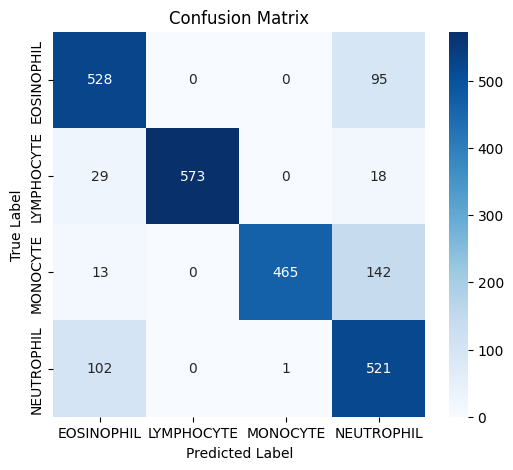

In [14]:
# Build a confusion matrix from the true and predicted labels
# This helps show which cell types the model gets right
# and which ones it tends to confuse
confusion_df = pd.crosstab(
    index=results_df["true_label"],
    columns=results_df["predicted_label"]
)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_df,
    annot=True,   # show the counts in each cell
    fmt="d",      # display values as integers
    cmap="Blues"  # darker blue means a higher count
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

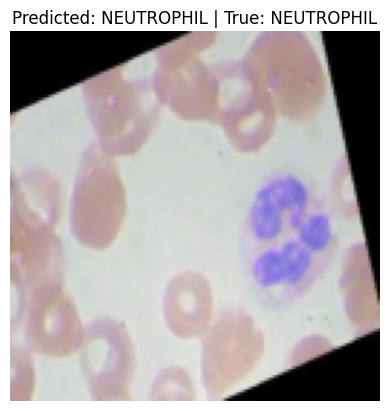

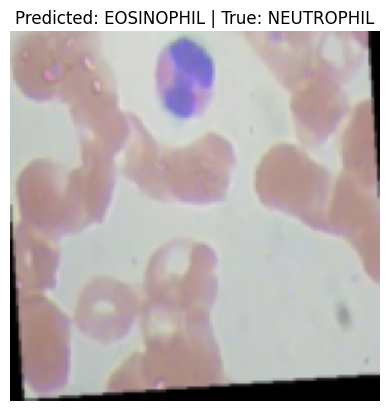

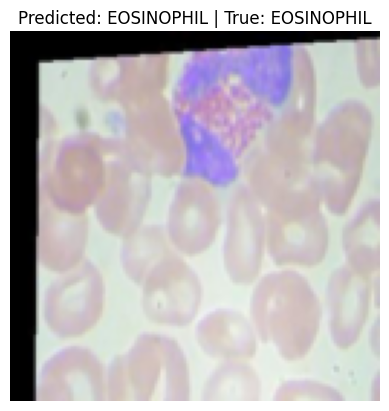

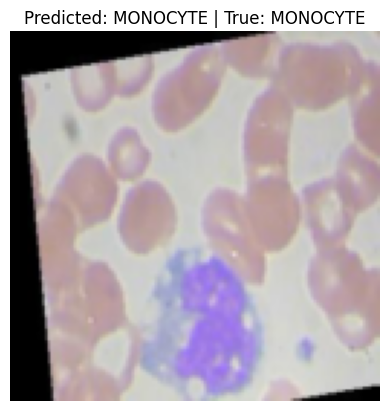

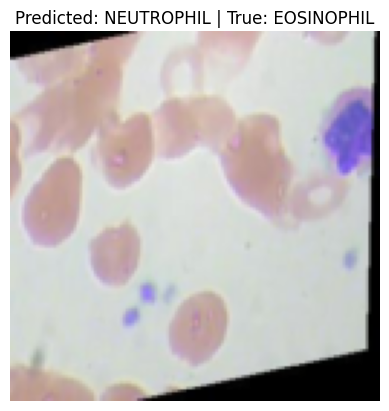

In [15]:
# Optional: show a few sample predictions for visual inspection

with torch.no_grad():
    # Take one random batch
    images, labels = next(iter(test_loader))

    # Move to device
    images = images.to(device)
    labels = labels.to(device)

    # Get predictions
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Move data back to CPU for plotting
images_cpu = images.cpu()
labels_cpu = labels.cpu()
predicted_cpu = predicted.cpu()

# Plot 5 example predictions
for i in range(5):
    img = images_cpu[i].clone()

    # Undo normalization so the image displays correctly
    img = img * 0.5 + 0.5

    # Convert from [C, H, W] to [H, W, C]
    img = img.permute(1, 2, 0)

    plt.figure()
    plt.imshow(img)
    plt.title(
        f"Predicted: {test_dataset.classes[predicted_cpu[i].item()]} | "
        f"True: {test_dataset.classes[labels_cpu[i].item()]}"
    )
    plt.axis("off")
    plt.show()